#First

In [1]:
import pandas as pd
import torch

# This automatically detects if a GPU (CUDA) is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load the train and test files
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

# Look at the first 5 rows of your training data
print(train.head())

# Check how much data you have
print(f"\nTraining set size: {len(train)} rows")


Using device: cuda
   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  

Training set size: 120000 rows


Class Distribution:
Class Index
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64


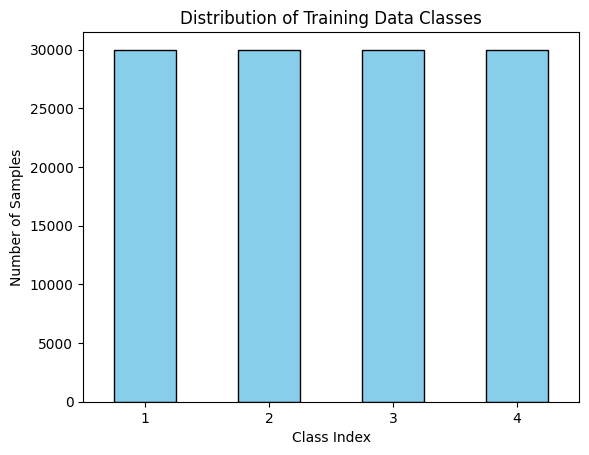

In [2]:
import matplotlib.pyplot as plt

# Count occurrences of each class index
class_counts = train["Class Index"].value_counts().sort_index()

print("Class Distribution:")
print(class_counts)

# Visualize the distribution
class_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Distribution of Training Data Classes")
plt.xlabel("Class Index")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np


class ModelEvaluator:
    def __init__(self, y_true, y_pred, class_names=None):
        """
        y_true and y_pred should be numpy arrays or lists.
        class_names: list of strings (e.g., ["Sports", "World", ...])
        """
        self.y_true = y_true
        self.y_pred = y_pred
        self.class_names = (
            class_names
            if class_names
            else [f"{i + 1}" for i in range(len(np.unique(y_true)))]
        )

    def show_report(self):
        print("\n--- Classification Report ---")
        print(
            classification_report(
                self.y_true, self.y_pred, target_names=self.class_names
            )
        )

    def plot_confusion_matrix(self):
        cm = confusion_matrix(self.y_true, self.y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=self.class_names,
            yticklabels=self.class_names,
        )
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()

    def plot_f1_scores(self):
        f1_scores = f1_score(self.y_true, self.y_pred, average=None) * 100

        min_score = min(f1_scores)
        max_score = max(f1_scores)

        padding = 5
        bottom = max(0, min_score - padding)
        top = min(100, max_score + padding)

        plt.figure(figsize=(10, 5))
        plt.bar(self.class_names, f1_scores, color="skyblue")
        plt.ylabel("F1-Score (%)")
        plt.title("F1-Score per Class")
        plt.ylim(bottom, top)
        plt.show()

    def save_errors(self, texts, filename="model_errors.csv"):
        """
        Filters wrong predictions and saves them to a CSV with readable labels.
        texts: list or array of the original input strings
        """
        # Create a dataframe for easy handling
        df = pd.DataFrame(
            {"text": texts, "actual_idx": self.y_true, "predicted_idx": self.y_pred}
        )

        # Filter for errors
        errors = df[df["actual_idx"] != df["predicted_idx"]].copy()

        # Map indices to names if possible
        if self.class_names:
            errors["actual_label"] = [self.class_names[i-1] for i in errors["actual_idx"]]
            errors["predicted_label"] = [self.class_names[i-1] for i in errors["predicted_idx"]]

        final_errors = pd.DataFrame(
            {
                "text": errors["text"],
                "Actual Class": errors["actual_label"],
                "Predicted Class": errors["predicted_label"],
            }
        )
        final_errors.to_csv(filename, index=False)
        print(f"Success: {len(errors)} errors saved to '{filename}'")
        return final_errors

In [4]:
# Combine Title and Description into a single 'text' column
train["text"] = train["Title"] + " " + train["Description"]
test["text"] = test["Title"] + " " + test["Description"]

# Keep only the columns we need (the Class index and the combined text)
train = train[["Class Index", "text"]]
test = test[["Class Index", "text"]]

# shuffle the data so there isn't any bias 
train = train.sample(frac=1, random_state=42).reset_index(drop=True)
test = test.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the first few rows
print(train.head())


   Class Index                                               text
0            3  BBC set for major shake-up, claims newspaper L...
1            3  Marsh averts cash crunch Embattled insurance b...
2            2  Jeter, Yankees Look to Take Control (AP) AP - ...
3            4  Flying the Sun to Safety When the Genesis caps...
4            3  Stocks Seen Flat as Nortel and Oil Weigh  NEW ...


In [5]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.svm import LinearSVC
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import classification_report

# # 1. Create the pipeline
# # TFIDF -> SVM 
# model = Pipeline(
#     [
#         ("tfidf", TfidfVectorizer(stop_words="english", max_features=10000)),
#         ("svm", LinearSVC()),
#     ]
# )

# # 2. Train the model
# print("Training the model...")
# model.fit(train["text"], train["Class Index"])
# print("Training complete!")

# # 3. Test the model
# print("\nEvaluating on test set...")
# predictions = model.predict(test["text"])
# print(classification_report(test["Class Index"], predictions))

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC



# 2. Define your Pipeline
pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), stop_words="english",max_features=5000)),
        ("clf", LinearSVC()),
    ]
)

# 3. Use cross_val_score on the 80% (X_train_val)
# This automates the internal training/testing folds for you.
cv_scores = cross_val_score(
    pipeline, train["text"], train["Class Index"], cv=5, scoring="f1_macro"
)
print(f"Mean CV Score: {cv_scores.mean():.4f}")

# 4. Final Evaluation (Only after tuning is done)
pipeline.fit(train['text'], train['Class Index'])
final_score = pipeline.score(test['text'], test['Class Index'])
print(f"Final Hold-out Score: {final_score:.4f}")

Mean CV Score: 0.9074
Final Hold-out Score: 0.9074



--- Classification Report ---
              precision    recall  f1-score   support

           1       0.93      0.90      0.91      1900
           2       0.95      0.98      0.96      1900
           3       0.87      0.87      0.87      1900
           4       0.88      0.89      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



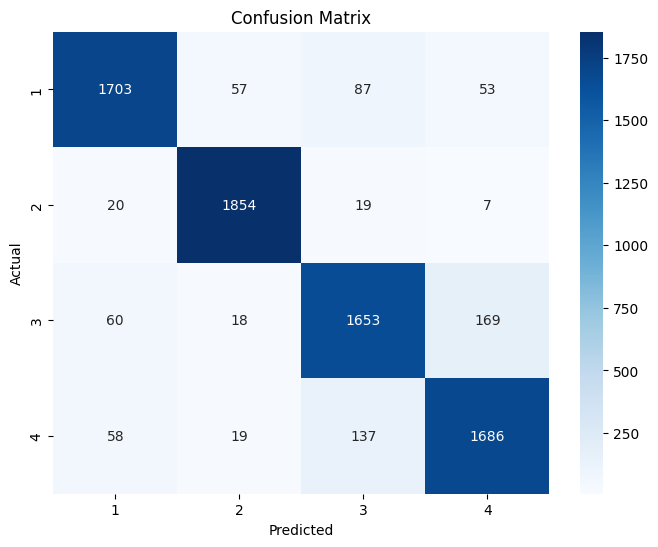

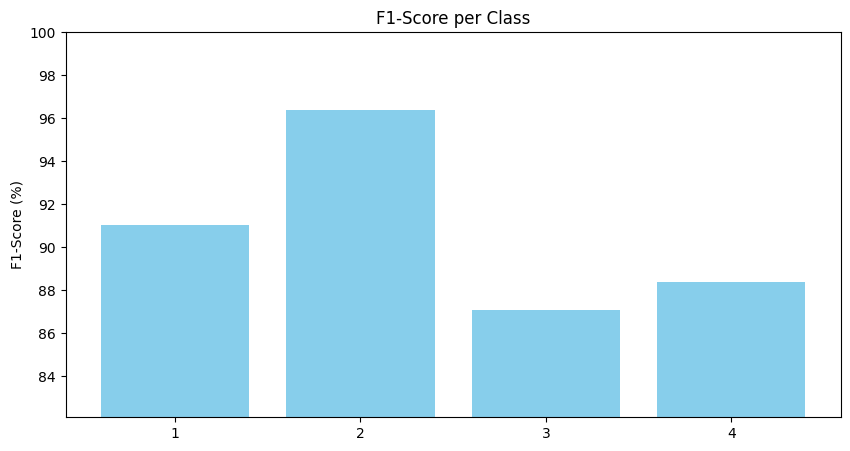

Success: 704 errors saved to 'TF-IDF_errors.csv'


,text,Actual Class,Predicted Class
1,Paris Tourists Search for Key to 'Da Vinci Cod...,1,4
9,Chavez rejects CD as opposition Venezuela #39;...,3,1
18,Clouds darken PeopleSoft conference SAN FRANCI...,3,4
27,Old bones unearth new date for giant deer #39;...,4,3
43,Ramirez should be taking it to heart When it c...,2,4
...,...,...,...
7568,Feds Mum on Pre-Election Terror Threat (AP) AP...,1,4
7570,"Panasonic, Toshiba delve into alternate energy...",4,3
7573,Delta #39;s Aborted Crash Landing If you #39;v...,3,4
7580,Britons still prefer fish n'chips (AFP) AFP - ...,1,4


In [6]:
# 1. Generate predictions
tfidf_preds = pipeline.predict(test["text"])
tfidf_labels = test["Class Index"]  

# 2. Initialize the evaluator
evaluator = ModelEvaluator(
    y_true=tfidf_labels,
    y_pred=tfidf_preds,
)

# 3. Call the methods
evaluator.show_report()
evaluator.plot_confusion_matrix()
evaluator.plot_f1_scores()
evaluator.save_errors(texts=test["text"],filename="TF-IDF_errors.csv")